# 第 4 章:GPT 模型架构

把前几章的积木拼成完整 GPT:

```
GPTModel
├── token_emb + pos_emb              (ch02)
├── N × TransformerBlock
│   ├── LayerNorm + MultiHeadAttention + Dropout + 残差
│   └── LayerNorm + FeedForward(Linear→GELU→Linear) + Dropout + 残差
├── LayerNorm (final)
└── 输出投影 Linear(d_model → vocab_size)
```

**章节内容**
1. LayerNorm(手写一遍)
2. GELU 激活函数
3. FeedForward
4. TransformerBlock
5. GPTModel(完整组装)
6. 参数量检查 + 随机权重生成测试
7. 封装到 `llm/model.py`

**参考配置**(对齐 GPT-2 small)
```python
GPT_CONFIG_124M = dict(
    vocab_size=50257, context_length=1024,
    emb_dim=768, n_heads=12, n_layers=12,
    drop_rate=0.1, qkv_bias=False,
)
```

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import torch
import torch.nn as nn
from llm.attention import MultiHeadAttention

torch.manual_seed(123)

# 我们先用一个小的测试配置,跑通后再换成 124M 标准配置
TEST_CFG = dict(
    vocab_size=50257,
    context_length=16,
    emb_dim=48,
    n_heads=4,
    n_layers=2,
    drop_rate=0.1,
    qkv_bias=False,
)

---
## 1. LayerNorm

**作用**:把每个 token 向量的 d_model 维特征归一化为均值 0、方差 1,再做一次
可学习的缩放 + 偏移。这样可以稳定训练、加速收敛。

**公式**
```
mean = x.mean(-1)
var  = x.var(-1)
y    = (x - mean) / sqrt(var + eps)
out  = scale * y + shift
```

**与 BatchNorm 的区别**
- BatchNorm 沿 batch 维度统计,依赖 batch 大小
- LayerNorm 沿特征维度统计,每个样本独立 —— 对变长序列更合适

In [2]:
# TODO: 实现 LayerNorm

class LayerNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        # TODO: 两个可学习参数
        # self.scale = nn.Parameter(torch.ones(emb_dim))
        self.scale = nn.Parameter(torch.ones(emb_dim))
        # self.shift = nn.Parameter(torch.zeros(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        # TODO:
        # mean = x.mean(dim=-1, keepdim=True)
        mean = x.mean(dim=-1, keepdim=True)
        # var  = x.var(dim=-1, keepdim=True, unbiased=False)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        # norm = (x - mean) / torch.sqrt(var + self.eps)
        norm = (x - mean) / torch.sqrt(var + self.eps)
        # return self.scale * norm + self.shift
        return self.scale * norm + self.shift


# 验证
ln = LayerNorm(emb_dim=5)
x = torch.randn(2, 3, 5) * 10 + 5
y = ln(x)
print('输入均值:', x.mean(-1).round(decimals=3))
print('输入方差:', x.var(-1, unbiased=False).round(decimals=3))
print('归一化后均值:', y.mean(-1).round(decimals=3))   # 应接近 0
print('归一化后方差:', y.var(-1, unbiased=False).round(decimals=3))  # 应接近 1

输入均值: tensor([[ 4.2330,  4.2720, 10.4640],
        [-2.6620,  7.1040,  9.0200]])
输入方差: tensor([[ 13.5090,  52.2420, 129.5970],
        [141.6510, 100.9600,  40.9840]])
归一化后均值: tensor([[0., 0., 0.],
        [0., -0., -0.]], grad_fn=<RoundBackward1>)
归一化后方差: tensor([[1., 1., 1.],
        [1., 1., 1.]], grad_fn=<RoundBackward1>)


---
## 2. GELU 激活函数

ReLU 在 0 处不可导、负半轴直接为 0,容易死神经元。
GELU (Gaussian Error Linear Unit) 是平滑版本,GPT-2 及后续模型都用它。

**近似公式**(GPT-2 使用的 tanh 近似)
```
GELU(x) ≈ 0.5 * x * (1 + tanh(sqrt(2/π) * (x + 0.044715 * x^3)))
```

PyTorch 内置了 `nn.GELU(approximate='tanh')`,这里手写一个加深理解。

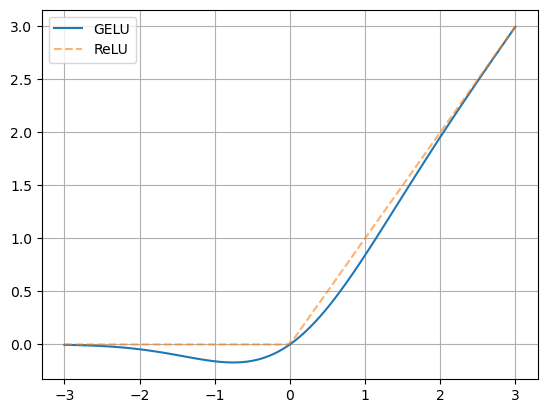

In [4]:
import math

class GELU(nn.Module):
    def forward(self, x):
        # TODO: 实现 GELU 的 tanh 近似
        # return 0.5 * x * (1 + torch.tanh(math.sqrt(2.0/math.pi) * (x + 0.044715 * x**3)))
        return 0.5 * x * (1 + torch.tanh(math.sqrt(2.0/math.pi) * (x + 0.044715 * x**3)))

# 画一下看看
import matplotlib.pyplot as plt
g = GELU()
xs = torch.linspace(-3, 3, 100)
plt.plot(xs, g(xs), label='GELU')
plt.plot(xs, torch.relu(xs), '--', label='ReLU', alpha=0.6)
plt.grid(True); plt.legend(); plt.show()

---
## 3. FeedForward

Transformer Block 里 attention 之后接一个两层 MLP,通常中间层放大 4 倍:

```
x: (B, T, d_model)
  -> Linear(d_model, 4*d_model)
  -> GELU
  -> Linear(4*d_model, d_model)
输出同 shape
```

这一段其实就是模型主要的「思考」发生地 —— attention 负责在 token 之间交换信息,
FFN 负责对每个位置的向量做非线性变换。

In [ ]:
# TODO: 实现 FeedForward

class FeedForward(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        # TODO: self.net = nn.Sequential(Linear, GELU, Linear)
        ...

    def forward(self, x):
        return self.net(x)

ffn = FeedForward(emb_dim=48)
test = torch.randn(2, 5, 48)
print('输入:', test.shape, '输出:', ffn(test).shape)  # 同 shape

---
## 4. TransformerBlock

```
x ──→ LayerNorm ──→ MHA ──→ Dropout ──┐
│                                      │
└──────────────── + ←──────────────────┘       残差连接 1
                  │
                  ▼
            LayerNorm ──→ FFN ──→ Dropout ──┐
                  │                          │
                  └──────────── + ←──────────┘  残差连接 2
                                │
                                ▼
                              output
```

注意这是 **pre-LN** 结构(LayerNorm 在子层之前),GPT-2 及后续模型标准做法。

In [ ]:
# TODO: 实现 TransformerBlock

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = LayerNorm(cfg['emb_dim'])
        self.attn = MultiHeadAttention(
            d_in=cfg['emb_dim'], d_out=cfg['emb_dim'],
            context_length=cfg['context_length'],
            num_heads=cfg['n_heads'], dropout=cfg['drop_rate'],
            qkv_bias=cfg['qkv_bias'],
        )
        self.ln2 = LayerNorm(cfg['emb_dim'])
        self.ffn = FeedForward(cfg['emb_dim'])
        self.drop = nn.Dropout(cfg['drop_rate'])

    def forward(self, x):
        # TODO:
        # x = x + self.drop(self.attn(self.ln1(x)))   # 残差 1
        # x = x + self.drop(self.ffn(self.ln2(x)))    # 残差 2
        # return x
        ...

block = TransformerBlock(TEST_CFG)
test = torch.randn(2, 10, 48)
print('TransformerBlock 输出 shape:', block(test).shape)

---
## 5. GPTModel(完整组装)

In [ ]:
# TODO: 实现 GPTModel

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        # TODO:
        # self.tok_emb  = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        # self.pos_emb  = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        # self.drop_emb = nn.Dropout(cfg['drop_rate'])
        # self.blocks   = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg['n_layers'])])
        # self.final_ln = LayerNorm(cfg['emb_dim'])
        # self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias=False)
        ...

    def forward(self, idx):
        # idx: (B, T) 的整数 token id
        B, T = idx.shape
        # TODO:
        # tok = self.tok_emb(idx)
        # pos = self.pos_emb(torch.arange(T, device=idx.device))
        # x   = self.drop_emb(tok + pos)
        # x   = self.blocks(x)
        # x   = self.final_ln(x)
        # logits = self.out_head(x)
        # return logits      # (B, T, vocab_size)
        ...


# 用小配置验证
model = GPTModel(TEST_CFG)
dummy = torch.randint(0, TEST_CFG['vocab_size'], (2, 10))
logits = model(dummy)
print('输入 shape:', dummy.shape)    # (2, 10)
print('输出 shape:', logits.shape)   # (2, 10, 50257)

---
## 6. 参数量检查 + 尝试生成

In [ ]:
# 用 GPT-2 small 配置检查参数量是否和官方 124M 对齐
GPT_CONFIG_124M = dict(
    vocab_size=50257, context_length=1024,
    emb_dim=768, n_heads=12, n_layers=12,
    drop_rate=0.1, qkv_bias=False,
)

big_model = GPTModel(GPT_CONFIG_124M)
n_params = sum(p.numel() for p in big_model.parameters())
print(f'参数总量: {n_params:,} ≈ {n_params/1e6:.2f} M')
# 预期约 163M(因为 embedding 没和 out_head 做权重共享;GPT-2 官方做了权重共享所以是 124M)

# 内存大致估算(float32)
mem_mb = n_params * 4 / (1024 * 1024)
print(f'float32 权重占显存: {mem_mb:.1f} MB')

In [ ]:
# 贪心解码(用未训练的模型,生成结果是乱码,但验证流程)

def generate_greedy(model, idx, max_new_tokens, context_length):
    """
    idx: (B, T) 初始 prompt 的 token id
    每一步:取最后一个位置的 logits,argmax 得到下一个 token,append 回去
    """
    model.eval()
    for _ in range(max_new_tokens):
        # 只取最后 context_length 个(超出部分截断)
        idx_cond = idx[:, -context_length:]
        with torch.no_grad():
            logits = model(idx_cond)              # (B, T, V)
        next_logits = logits[:, -1, :]            # 取最后一个位置:(B, V)
        next_id = next_logits.argmax(-1, keepdim=True)  # (B, 1)
        idx = torch.cat([idx, next_id], dim=1)
    return idx


from llm.tokenizer import Tokenizer
tokenizer = Tokenizer()
prompt = 'Hello, I am'
ids = torch.tensor([tokenizer.encode(prompt)])
out = generate_greedy(model, ids, max_new_tokens=5, context_length=TEST_CFG['context_length'])
print('生成的 id 序列:', out.tolist())
print('生成的文本(未训练,乱码正常):', tokenizer.decode(out[0].tolist()))

---
## 7. 封装到 `llm/model.py`

In [ ]:
import pathlib

code = '''
import math
import torch
import torch.nn as nn

from .attention import MultiHeadAttention


class LayerNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + self.eps) + self.shift


class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            math.sqrt(2.0 / math.pi) * (x + 0.044715 * x ** 3)
        ))


class FeedForward(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, 4 * emb_dim),
            GELU(),
            nn.Linear(4 * emb_dim, emb_dim),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = LayerNorm(cfg["emb_dim"])
        self.attn = MultiHeadAttention(
            d_in=cfg["emb_dim"], d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ln2 = LayerNorm(cfg["emb_dim"])
        self.ffn = FeedForward(cfg["emb_dim"])
        self.drop = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        x = x + self.drop(self.attn(self.ln1(x)))
        x = x + self.drop(self.ffn(self.ln2(x)))
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.tok_emb  = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb  = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.blocks   = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_ln = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, idx):
        B, T = idx.shape
        tok = self.tok_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=idx.device))
        x   = self.drop_emb(tok + pos)
        x   = self.blocks(x)
        x   = self.final_ln(x)
        return self.out_head(x)


GPT_CONFIG_124M = dict(
    vocab_size=50257, context_length=1024,
    emb_dim=768, n_heads=12, n_layers=12,
    drop_rate=0.1, qkv_bias=False,
)
'''.lstrip()

out = pathlib.Path('../llm/model.py')
out.write_text(code, encoding='utf-8')
print(f'已写入 {out.resolve()}')

# 验证
import sys, importlib
for m in ['llm.model', 'llm.attention']:
    if m in sys.modules:
        importlib.reload(sys.modules[m])
from llm.model import GPTModel as GPT2, GPT_CONFIG_124M as CFG
m2 = GPT2(TEST_CFG)
_out = m2(torch.randint(0, TEST_CFG['vocab_size'], (2, 10)))
assert _out.shape == (2, 10, TEST_CFG['vocab_size'])
print('llm.model 验证通过')

---
## 章末思考题

1. 为什么 TransformerBlock 要有两次残差连接?去掉会发生什么?
2. GPT-2 官方 124M 用了 embedding 和 out_head 权重共享,这能节省多少参数?
3. 增大 n_layers 和增大 emb_dim,哪个对参数量的影响更大?给一个粗略估算。

答完进入第 5 章 —— 见证奇迹的预训练环节!